# Nested NER for Arabic — the Rabt AdaptNER system, end to end

This notebook teaches, and lets you reproduce, the Subtask 1 system of *Rabt
at KnowledgeGraphEval 2026* (ArabicNLP 2026): a multi-head nested-BIO tagger
for Arabic entities — including entities nested inside other entities — as
the first stage of knowledge-graph construction. Everything runs live on a
synthetic Arabic toy corpus; the system code is vendored verbatim. Companion:
the paper (`paper/latex/main.tex`) + `docs/learning-corner/paper-companion.md`.

**How to use:** Runtime → T4 GPU → Run all. Default: *quick path* (toy data,
minutes); `KGEVAL_FULL=1` + **Real data** (§3) / **Full replication** (§11)
reproduce the paper's numbers.

## 1. What we're building

A knowledge graph stores facts as typed nodes (entities) and edges (relations)
— and before you can add edges, you need the nodes. Subtask 1 (**AdaptNER**)
is that first stage: **named entity recognition** over 21 types (PERS, ORG,
GPE, LOC, DATE, …). The twist is that entities **nest**: *جامعة بيرزيت*
(Birzeit University) is an ORG containing *بيرزيت*, a GPE — and 22.5% of
mentions in the training corpus are nested.

Training data is **Wojood** (~550K tokens, mostly news). The blind test is
**Konooz**: 50,175 tokens from ten domains never seen in training. Robustness
under that domain shift — not in-domain accuracy — is the object of study.

## 2. Setup

Three things happen next: check the GPU and libraries, vendor the team's
`kgeval` package into this runtime as literal source files (so the notebook
is self-contained and you can read every line of the system it teaches), and
set the two run knobs — the encoder checkpoint and the quick-vs-full switch.

In [ ]:
try:
    import torch
    import transformers
except ImportError:  # fresh runtime without the ML stack
    %pip install -q torch transformers
    import torch
    import transformers

print(f"torch {torch.__version__} | transformers {transformers.__version__}")
print("CUDA GPU available:", torch.cuda.is_available(), "(want True on a Colab T4)")

torch 2.11.0+cu128 | transformers 5.13.1
CUDA GPU available: True (want True on a Colab T4)


In [ ]:
import os
os.makedirs("kgeval", exist_ok=True)
print("writing kgeval package into", os.getcwd())

writing kgeval package into /content


In [ ]:
%%writefile kgeval/__init__.py
"""Team Rabt tooling for KnowledgeGraphEval 2026 (AdaptNER + Relation Extraction).

Format contracts implemented here are specified in
docs/knowledgegrapheval_2026_solution_design.md §1 and were verified against the
local task data and the Codabench page captures.
"""

__version__ = "0.1.0"


Overwriting kgeval/__init__.py


In [ ]:
%%writefile kgeval/columns.py
"""Canonical AdaptNER column contract.

The Codabench scorer reads the 21 tag columns positionally in this fixed
(alphabetical) order — a wrong order scores silently wrong, so every module
that touches the 22-field format imports the constants from here and nowhere
else.
"""

ENTITY_TYPES: tuple[str, ...] = (
    "CARDINAL",
    "CURR",
    "DATE",
    "EVENT",
    "FAC",
    "GPE",
    "LANGUAGE",
    "LAW",
    "LOC",
    "MONEY",
    "NORP",
    "OCC",
    "ORDINAL",
    "ORG",
    "PERCENT",
    "PERS",
    "PRODUCT",
    "QUANTITY",
    "TIME",
    "UNIT",
    "WEBSITE",
)

NUM_TYPES = len(ENTITY_TYPES)
TYPE_INDEX: dict[str, int] = {t: i for i, t in enumerate(ENTITY_TYPES)}

assert NUM_TYPES == 21
assert list(ENTITY_TYPES) == sorted(ENTITY_TYPES), "contract order is alphabetical"

# The 10 Konooz domains; submissions concatenate domain files in sorted() order.
# Validators derive the actual order from the released test directory listing and
# cross-check it against this fallback.
KONOOZ_DOMAINS: tuple[str, ...] = (
    "Agriculture",
    "Art",
    "Economics",
    "Finance",
    "Health",
    "History",
    "Law",
    "Politics",
    "Science",
    "Sport",
)


def valid_column_tags(type_name: str) -> frozenset[str]:
    """The only strings admissible in the column of `type_name`."""
    return frozenset(("O", f"B-{type_name}", f"I-{type_name}"))


Overwriting kgeval/columns.py


In [ ]:
%%writefile kgeval/chunking.py
"""Split long sentences into sub-budget chunks at word boundaries.

Wojood has sentences longer than the 512-subtoken encoder window (design doc
§3.2: split at token boundaries, re-join at write-out). Chunking is pure
arithmetic over per-word subtoken costs so it can be unit-tested without a
tokenizer; predictions are re-assembled by (sentence index, word offset).
"""

from __future__ import annotations

from typing import Sequence


def chunk_spans(word_costs: Sequence[int], budget: int) -> list[tuple[int, int]]:
    """Greedy [start, end) word ranges whose summed cost stays within budget.

    A single word over budget still gets its own chunk (the tokenizer truncates
    it; only the first subtoken is labeled anyway).
    """
    if budget <= 0:
        raise ValueError(f"budget must be positive, got {budget}")
    spans: list[tuple[int, int]] = []
    start = 0
    acc = 0
    for i, cost in enumerate(word_costs):
        if acc and acc + cost > budget:
            spans.append((start, i))
            start = i
            acc = 0
        acc += cost
    if word_costs:
        spans.append((start, len(word_costs)))
    return spans


Overwriting kgeval/chunking.py


In [ ]:
%%writefile kgeval/spans.py
"""Per-column BIO decoding with IOB repair, and span-set extraction.

Spans are (start, end_exclusive, type) over token positions within one
sentence. An `I-x` with no open span of type x (after O or at sentence start)
starts a new span and is counted as a repair — the standard IOB2 repair, also
applied to model output before submission writing.
"""

from __future__ import annotations

from collections import Counter
from dataclasses import dataclass

from .columns import ENTITY_TYPES, TYPE_INDEX

Span = tuple[int, int, str]


@dataclass
class DecodeResult:
    spans: set[Span]
    n_repairs: int = 0


def decode_bio_column(tags: list[str], type_name: str) -> DecodeResult:
    """Decode one type column of one sentence."""
    spans: set[Span] = set()
    repairs = 0
    start: int | None = None
    for i, tag in enumerate(tags):
        if tag == "O":
            if start is not None:
                spans.add((start, i, type_name))
                start = None
        elif tag == f"B-{type_name}":
            if start is not None:
                spans.add((start, i, type_name))
            start = i
        elif tag == f"I-{type_name}":
            if start is None:  # orphan I- → repaired to a span start
                start = i
                repairs += 1
        else:
            raise ValueError(f"tag {tag!r} not admissible in column {type_name}")
    if start is not None:
        spans.add((start, len(tags), type_name))
    return DecodeResult(spans=spans, n_repairs=repairs)


def spans_from_rows(tag_rows: list[list[str]]) -> DecodeResult:
    """All typed spans of one sentence given per-token 21-tag rows."""
    all_spans: set[Span] = set()
    repairs = 0
    for ci, type_name in enumerate(ENTITY_TYPES):
        column = [row[ci] for row in tag_rows]
        res = decode_bio_column(column, type_name)
        all_spans |= res.spans
        repairs += res.n_repairs
    return DecodeResult(spans=all_spans, n_repairs=repairs)


def encode_spans_to_rows(spans: set[Span] | list[Span], n_tokens: int) -> list[list[str]]:
    """Per-token 21-tag rows from a span set (inverse of spans_from_rows).

    Same-type spans must be non-overlapping — a per-type BIO column cannot
    encode same-type overlap; resolve conflicts first (see union_tag_rows).
    Adjacent same-type spans round-trip: the second one starts with B-.
    """
    rows = [["O"] * len(ENTITY_TYPES) for _ in range(n_tokens)]
    by_type: dict[str, list[Span]] = {}
    for span in spans:
        start, end, typ = span
        if not (0 <= start < end <= n_tokens):
            raise ValueError(f"span {span} out of bounds for {n_tokens} tokens")
        by_type.setdefault(typ, []).append(span)
    for typ, tspans in by_type.items():
        ci = TYPE_INDEX[typ]
        prev_end = -1
        for start, end, _ in sorted(tspans):
            if start < prev_end:
                raise ValueError(f"overlapping {typ} spans cannot share a BIO column")
            rows[start][ci] = f"B-{typ}"
            for i in range(start + 1, end):
                rows[i][ci] = f"I-{typ}"
            prev_end = end
    return rows


@dataclass
class EnsembleResult:
    rows: list[list[str]]
    spans: set[Span]
    n_dropped: int  # candidates discarded by same-type overlap resolution


def union_tag_rows(
    rows_per_model: list[list[list[str]]], min_votes: int = 1
) -> EnsembleResult:
    """Span-level vote ensemble of one sentence tagged by several models.

    Decodes each model's spans (IOB repair applied), keeps spans reaching
    min_votes (1 = pure union — the recall lever), then resolves same-type
    overlaps greedily by (votes desc, length desc, start asc) since a BIO
    column cannot encode same-type overlap. Deterministic given input order.
    """
    if not rows_per_model:
        raise ValueError("need at least one model's rows")
    n_tokens = len(rows_per_model[0])
    if any(len(rows) != n_tokens for rows in rows_per_model):
        raise ValueError("models disagree on sentence length")
    votes: Counter[Span] = Counter()
    for rows in rows_per_model:
        votes.update(spans_from_rows(rows).spans)
    candidates = sorted(
        (s for s, v in votes.items() if v >= min_votes),
        key=lambda s: (-votes[s], -(s[1] - s[0]), s[0], s[2]),
    )
    accepted: list[Span] = []
    occupied: dict[str, list[tuple[int, int]]] = {}
    dropped = 0
    for start, end, typ in candidates:
        if any(start < e and b < end for b, e in occupied.get(typ, [])):
            dropped += 1
            continue
        accepted.append((start, end, typ))
        occupied.setdefault(typ, []).append((start, end))
    return EnsembleResult(
        rows=encode_spans_to_rows(accepted, n_tokens),
        spans=set(accepted),
        n_dropped=dropped,
    )


Overwriting kgeval/spans.py


In [ ]:
%%writefile kgeval/wojood.py
"""Readers for the Wojood nested release (training side of AdaptNER).

`train/val/test.txt` are token-per-line with a variable-length space-separated
tag list (1–5 tags), outer entity listed first, e.g. `ملز I-MONEY B-CURR`.
Blank lines separate sentences. The `.csv` twin adds `global_sentence_id` and
`Sub_corpus` — the join keys used by the RE task and by leave-subcorpus-out
model selection.
"""

from __future__ import annotations

import csv
import re
from dataclasses import dataclass, field
from pathlib import Path

from .columns import ENTITY_TYPES

# token, then 1..n tags; tags are O or [BI]-TYPE with TYPE from the 21-type set.
_TAG_RE = re.compile(r"^(O|[BI]-([A-Z]+))$")

# (token, [tags outer→inner]) per token.
Token = tuple[str, list[str]]
Sentence = list[Token]


@dataclass
class NestedCorpus:
    sentences: list[Sentence]
    anomalies: list[str] = field(default_factory=list)

    @property
    def n_tokens(self) -> int:
        return sum(len(s) for s in self.sentences)


def read_nested_txt(path: str | Path, strict: bool = True) -> NestedCorpus:
    """Parse a Wojood nested .txt file.

    strict=True raises on any malformed tag line; strict=False records the
    anomaly and keeps the line (unknown tags are preserved verbatim so the
    caller can inspect them).
    """
    sentences: list[Sentence] = []
    current: Sentence = []
    anomalies: list[str] = []

    with open(path, encoding="utf-8") as f:
        for lineno, raw in enumerate(f, start=1):
            line = raw.rstrip("\r\n")
            if not line.strip():
                if current:
                    sentences.append(current)
                    current = []
                continue
            parts = line.split()
            token, tags = parts[0], parts[1:]
            if not tags:
                anomalies.append(f"{path}:{lineno}: token line without tags: {line!r}")
                tags = ["O"]
            for tag in tags:
                m = _TAG_RE.match(tag)
                if not m or (m.group(2) is not None and m.group(2) not in ENTITY_TYPES):
                    anomalies.append(f"{path}:{lineno}: unknown tag {tag!r}")
            if "O" in tags and len(tags) > 1:
                anomalies.append(f"{path}:{lineno}: O combined with entity tags: {tags}")
            current.append((token, tags))
    if current:
        sentences.append(current)

    if strict and anomalies:
        preview = "\n".join(anomalies[:5])
        raise ValueError(
            f"{len(anomalies)} malformed tag lines in {path}; first cases:\n{preview}"
        )
    return NestedCorpus(sentences=sentences, anomalies=anomalies)


def read_sentence_subcorpus(csv_path: str | Path) -> dict[str, str]:
    """Map global_sentence_id → Sub_corpus from a Wojood .csv (file order kept)."""
    mapping: dict[str, str] = {}
    with open(csv_path, encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            gsid = row["global_sentence_id"]
            if gsid not in mapping:
                mapping[gsid] = row["Sub_corpus"]
    return mapping


def read_csv_sentences(csv_path: str | Path) -> dict[str, list[str]]:
    """Map global_sentence_id → token list (for the RE sentence_id join)."""
    sentences: dict[str, list[str]] = {}
    with open(csv_path, encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            sentences.setdefault(row["global_sentence_id"], []).append(row["token"])
    return sentences


Overwriting kgeval/wojood.py


In [ ]:
%%writefile kgeval/convert.py
"""Convert Wojood variable-width nested tags → the fixed 21-column format.

Rule (design doc §1.1): each type column receives that type's B-/I- tag; on a
same-type collision (an inner and an outer entity of the same type on one
token) the OUTER (first-listed) tag wins. Same-type nesting is unrepresentable
in the official format; Wojood contains only ~576 such nested pairs corpus-wide,
so the loss is negligible — but it is counted and reported, never silent.
"""

from __future__ import annotations

from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

from .columns import ENTITY_TYPES, TYPE_INDEX
from .wojood import NestedCorpus, Sentence, read_nested_txt


@dataclass
class ConvertStats:
    n_sentences: int = 0
    n_tokens: int = 0
    n_multi_tag_tokens: int = 0
    n_same_type_collisions: int = 0
    collisions_by_type: Counter = field(default_factory=Counter)
    nesting_pairs: Counter = field(default_factory=Counter)  # (outer, inner) token counts


def nested_tags_to_columns(tags: list[str], stats: ConvertStats | None = None) -> list[str]:
    """One token's outer→inner tag list → its 21 column tags."""
    columns = ["O"] * len(ENTITY_TYPES)
    seen_types: list[str] = []
    for tag in tags:
        if tag == "O":
            continue
        typ = tag.split("-", 1)[1]
        ci = TYPE_INDEX[typ]
        if columns[ci] == "O":
            columns[ci] = tag
        elif stats is not None:
            stats.n_same_type_collisions += 1
            stats.collisions_by_type[typ] += 1
        if stats is not None:
            for outer in seen_types:
                stats.nesting_pairs[(outer, typ)] += 1
        seen_types.append(typ)
    return columns


def sentence_to_rows(sentence: Sentence, stats: ConvertStats | None = None) -> list[list[str]]:
    """One nested sentence → rows of [token, tag×21]."""
    rows = []
    for token, tags in sentence:
        if stats is not None:
            stats.n_tokens += 1
            if sum(1 for t in tags if t != "O") > 1:
                stats.n_multi_tag_tokens += 1
        rows.append([token] + nested_tags_to_columns(tags, stats))
    if stats is not None:
        stats.n_sentences += 1
    return rows


def convert_corpus(corpus: NestedCorpus) -> tuple[list[list[list[str]]], ConvertStats]:
    stats = ConvertStats()
    docs = [sentence_to_rows(s, stats) for s in corpus.sentences]
    return docs, stats


def convert_file(in_path: str | Path, out_path: str | Path, eol: str = "\n") -> ConvertStats:
    """Wojood nested .txt → 22-field column file (for training-side ingestion)."""
    corpus = read_nested_txt(in_path)
    docs, stats = convert_corpus(corpus)
    out = Path(out_path)
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w", encoding="utf-8", newline="") as f:
        for si, rows in enumerate(docs):
            for row in rows:
                f.write(" ".join(row) + eol)
            if si != len(docs) - 1:
                f.write(eol)  # blank line between sentences
    return stats


Overwriting kgeval/convert.py


In [ ]:
%%writefile kgeval/ner_data.py
"""Tensorization for the 21-head tagger.

Pipeline: docs (rows of [token, tag*21] from convert_corpus) → chunked
Examples → pre-collated length-sorted Batches (built once, order shuffled per
epoch) → argmax predictions re-assembled into per-sentence 21-tag rows that
plug straight into ner_scoring / adaptner_submission.

Only the first subtoken of each word carries labels (design §3.2); other
positions are -100 across all 21 columns, so one mask serves every head.
"""

from __future__ import annotations

from dataclasses import dataclass

import torch

from .chunking import chunk_spans
from .columns import ENTITY_TYPES

N_TYPES = len(ENTITY_TYPES)
_PREFIX = ("O", "B", "I")


def tag_id(tag: str) -> int:
    return 0 if tag == "O" else (1 if tag.startswith("B-") else 2)


def id_to_tag(i: int, type_name: str) -> str:
    return "O" if i == 0 else f"{_PREFIX[i]}-{type_name}"


@dataclass
class Example:
    sent_idx: int
    word_start: int
    words: list[str]
    tag_ids: list[list[int]] | None  # per word: 21 ints; None for unlabeled text
    n_subtokens: int


@dataclass
class Batch:
    enc: object  # BatchEncoding (keeps .word_ids); tensors inside
    labels: torch.Tensor  # [B, T, 21], -100 on non-first-subtoken/pad positions
    first_pos: list[list[int]]  # per example: word index → seq position (-1 if truncated away)
    examples: list[Example]


def build_examples(
    docs: list[list[list[str]]], tokenizer, max_len: int = 512
) -> list[Example]:
    """docs: sentences of [token, tag*21] rows (or bare [token] for unlabeled)."""
    budget = max_len - 2  # room for CLS/SEP
    examples: list[Example] = []
    for si, rows in enumerate(docs):
        words = [r[0] for r in rows]
        enc = tokenizer(words, is_split_into_words=True, add_special_tokens=False)
        costs = [0] * len(words)
        for wid in enc.word_ids():
            if wid is not None:
                costs[wid] += 1
        labeled = len(rows[0]) > 1
        for start, end in chunk_spans(costs, budget):
            chunk = rows[start:end]
            examples.append(
                Example(
                    sent_idx=si,
                    word_start=start,
                    words=[r[0] for r in chunk],
                    tag_ids=[[tag_id(t) for t in r[1:]] for r in chunk] if labeled else None,
                    n_subtokens=sum(costs[start:end]),
                )
            )
    return examples


def make_batches(
    examples: list[Example], tokenizer, batch_size: int, max_len: int = 512
) -> list[Batch]:
    """Length-sorted fixed batches, dynamically padded per batch."""
    batches: list[Batch] = []
    ordered = sorted(examples, key=lambda ex: ex.n_subtokens)
    for i in range(0, len(ordered), batch_size):
        group = ordered[i : i + batch_size]
        enc = tokenizer(
            [ex.words for ex in group],
            is_split_into_words=True,
            truncation=True,
            max_length=max_len,
            padding=True,
            return_tensors="pt",
        )
        n, t = enc["input_ids"].shape
        labels = torch.full((n, t, N_TYPES), -100, dtype=torch.long)
        first_pos: list[list[int]] = []
        for bi, ex in enumerate(group):
            pos_of_word = [-1] * len(ex.words)
            seen: set[int] = set()
            for pos, wid in enumerate(enc.word_ids(bi)):
                if wid is None or wid in seen:
                    continue
                seen.add(wid)
                pos_of_word[wid] = pos
                if ex.tag_ids is not None:
                    labels[bi, pos] = torch.as_tensor(ex.tag_ids[wid])
            first_pos.append(pos_of_word)
        batches.append(Batch(enc=enc, labels=labels, first_pos=first_pos, examples=group))
    return batches


def assemble_predictions(
    pred_ids: list[torch.Tensor], batches: list[Batch], sentence_lengths: list[int]
) -> list[list[list[str]]]:
    """argmax ids per batch [B, T, 21] → per-sentence 21-tag rows.

    Words the tokenizer dropped (zero subtokens, or truncated pathological
    chunks) stay all-O rather than going missing — row counts always match.
    """
    docs = [[["O"] * N_TYPES for _ in range(n)] for n in sentence_lengths]
    for preds, batch in zip(pred_ids, batches, strict=True):
        for bi, ex in enumerate(batch.examples):
            for wi, pos in enumerate(batch.first_pos[bi]):
                if pos < 0:
                    continue
                row = docs[ex.sent_idx][ex.word_start + wi]
                for ci in range(N_TYPES):
                    row[ci] = id_to_tag(int(preds[bi, pos, ci]), ENTITY_TYPES[ci])
    return docs


Overwriting kgeval/ner_data.py


In [ ]:
%%writefile kgeval/ner_model.py
"""Multi-head nested tagger + the A10 unified loss.

Architecture (design §3.1): encoder + one 3-way O/B/I softmax head per entity
type. The 21 heads are stored as a single Linear(hidden, 21*3) — each output
unit is independent, so this is the same math as 21 separate Linears in one
matmul.

Loss (A10, measured +1.18 nested on Wojood test):
    L = mean_head(LUL) + p · Var_head(LUL)
    LUL = 0.4·CE + 0.2·Dice + 0.2·Tversky(α=0.5) + 0.2·Focal(γ=2)
Dice/Tversky/Focal include the O class — A10 does not specify an exclusion.
"""

from __future__ import annotations

import torch
import torch.nn.functional as F
from torch import nn

from .columns import ENTITY_TYPES

N_TYPES = len(ENTITY_TYPES)


class MultiHeadTagger(nn.Module):
    """Both taggers share the interface run_training relies on:
    forward → logits; compute_loss(logits, labels) → (loss, parts);
    decode(logits) → tag ids [B, T, 21] with 0=O 1=B 2=I."""

    def __init__(
        self,
        encoder,
        dropout: float = 0.1,
        loss_lambdas: tuple[float, float, float, float] = (0.4, 0.2, 0.2, 0.2),
        tversky_alpha: float = 0.5,
        focal_gamma: float = 2.0,
        var_penalty: float = 5.0,
    ):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.Linear(encoder.config.hidden_size, N_TYPES * 3)
        self.loss_lambdas = loss_lambdas
        self.tversky_alpha = tversky_alpha
        self.focal_gamma = focal_gamma
        self.var_penalty = var_penalty

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        hidden = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state
        logits = self.heads(self.dropout(hidden))
        return logits.view(logits.shape[0], logits.shape[1], N_TYPES, 3)

    def compute_loss(
        self, logits: torch.Tensor, labels: torch.Tensor
    ) -> tuple[torch.Tensor, dict[str, float]]:
        return unified_loss(
            logits, labels, self.loss_lambdas,
            self.tversky_alpha, self.focal_gamma, self.var_penalty,
        )

    def decode(self, logits: torch.Tensor) -> torch.Tensor:
        return logits.argmax(dim=-1)


class SigmoidTagger(nn.Module):
    """B22's single-head multilabel variant (design §3.1 A/B candidate).

    One Linear(hidden, 43): a B- and I- output per type plus one O output,
    each sigmoid-activated; focal BCE (α=0.75, γ=1.0 per B22). Decode per
    type column: max(B, I) over threshold wins, else O — the O output only
    participates in the loss. Scored 92.30 vs 88.4 for the multi-task
    original on nested Wojood test (B22)."""

    def __init__(
        self,
        encoder,
        dropout: float = 0.1,
        focal_alpha: float = 0.75,
        focal_gamma: float = 1.0,
        threshold: float = 0.5,
    ):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(encoder.config.hidden_size, 2 * N_TYPES + 1)
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma
        self.threshold = threshold

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        hidden = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state
        return self.head(self.dropout(hidden))  # [B, T, 43]

    def _targets(self, labels: torch.Tensor) -> torch.Tensor:
        """labels [N, 21] with 0/1/2 → multilabel bits [N, 43]."""
        b_bits = (labels == 1).float()
        i_bits = (labels == 2).float()
        o_bit = (labels == 0).all(dim=-1, keepdim=True).float()
        return torch.cat([b_bits, i_bits, o_bit], dim=-1)

    def compute_loss(
        self, logits: torch.Tensor, labels: torch.Tensor
    ) -> tuple[torch.Tensor, dict[str, float]]:
        mask = labels[..., 0] != -100
        lg = logits[mask].float()  # [N, 43]
        targets = self._targets(labels[mask])
        p = torch.sigmoid(lg)
        pt = torch.where(targets > 0, p, 1 - p).clamp_min(1e-7)
        alpha_t = torch.where(
            targets > 0,
            torch.full_like(p, self.focal_alpha),
            torch.full_like(p, 1 - self.focal_alpha),
        )
        loss = (alpha_t * (1 - pt) ** self.focal_gamma * -pt.log()).mean()
        return loss, {"focal_bce": float(loss.detach())}

    def decode(self, logits: torch.Tensor) -> torch.Tensor:
        p = torch.sigmoid(logits.float())
        b_probs = p[..., :N_TYPES]
        i_probs = p[..., N_TYPES : 2 * N_TYPES]
        best = torch.maximum(b_probs, i_probs)
        tag_ids = torch.where(b_probs >= i_probs, 1, 2)
        return torch.where(best > self.threshold, tag_ids, torch.zeros_like(tag_ids))


def unified_loss(
    logits: torch.Tensor,
    labels: torch.Tensor,
    lambdas: tuple[float, float, float, float] = (0.4, 0.2, 0.2, 0.2),
    tversky_alpha: float = 0.5,
    focal_gamma: float = 2.0,
    var_penalty: float = 5.0,
    eps: float = 1e-6,
) -> tuple[torch.Tensor, dict[str, float]]:
    """logits [B, T, 21, 3]; labels [B, T, 21] with -100 on unlabeled positions.

    Labeled positions are identical across heads (first subtokens), so one mask
    serves all 21. Computed in fp32 even under autocast — the Dice/Tversky sums
    are batch-level reductions that lose precision in fp16.
    """
    mask = labels[..., 0] != -100
    lg = logits[mask].float()  # [N, 21, 3]
    y = labels[mask]  # [N, 21]
    if lg.shape[0] == 0:
        raise ValueError("no labeled positions in batch")
    logp = F.log_softmax(lg, dim=-1)
    p = logp.exp()
    y1 = F.one_hot(y, num_classes=3).float()  # [N, 21, 3]

    ce = -logp.gather(-1, y.unsqueeze(-1)).squeeze(-1).mean(dim=0)  # [21]
    inter = (p * y1).sum(dim=0)  # [21, 3]
    dice = 1 - ((2 * inter + eps) / ((p * p).sum(dim=0) + y1.sum(dim=0) + eps)).mean(dim=-1)
    fp = (p * (1 - y1)).sum(dim=0)
    fn = ((1 - p) * y1).sum(dim=0)
    tversky = 1 - (
        (inter + eps) / (inter + tversky_alpha * fp + (1 - tversky_alpha) * fn + eps)
    ).mean(dim=-1)
    pt = p.gather(-1, y.unsqueeze(-1)).squeeze(-1).clamp_min(eps)  # [N, 21]
    focal = ((1 - pt) ** focal_gamma * -pt.log()).mean(dim=0)  # [21]

    l_ce, l_di, l_tv, l_fl = lambdas
    per_head = l_ce * ce + l_di * dice + l_tv * tversky + l_fl * focal  # [21]
    variance = per_head.var(unbiased=False)
    total = per_head.mean() + var_penalty * variance
    parts = {
        "ce": float(ce.mean().detach()),
        "dice": float(dice.mean().detach()),
        "tversky": float(tversky.mean().detach()),
        "focal": float(focal.mean().detach()),
        "head_var": float(variance.detach()),
    }
    return total, parts


Overwriting kgeval/ner_model.py


In [ ]:
%%writefile kgeval/ner_scoring.py
"""Entity-level micro-F1 (exact span + type) for the AdaptNER track.

Mirrors the announced metric: an entity counts as correct only if span
boundaries and type both match. To be reconciled against the official
evaluation script from the starting kit the moment it is on disk (design doc
§1.3 open item 1).
"""

from __future__ import annotations

from collections import Counter
from dataclasses import dataclass, field

from .spans import Span, spans_from_rows


def _prf(tp: int, fp: int, fn: int) -> tuple[float, float, float]:
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * p * r / (p + r) if p + r else 0.0
    return p, r, f1


@dataclass
class NERScore:
    tp: int = 0
    fp: int = 0
    fn: int = 0
    per_type: dict[str, tuple[int, int, int]] = field(default_factory=dict)
    n_pred_repairs: int = 0

    @property
    def micro(self) -> tuple[float, float, float]:
        return _prf(self.tp, self.fp, self.fn)

    def pretty(self) -> str:
        p, r, f1 = self.micro
        lines = [
            f"micro-P {p:.4f}  micro-R {r:.4f}  micro-F1 {f1:.4f}  "
            f"(TP {self.tp} FP {self.fp} FN {self.fn}; IOB repairs in pred: {self.n_pred_repairs})"
        ]
        for typ in sorted(self.per_type):
            tp, fp, fn = self.per_type[typ]
            tp_, tr_, tf_ = _prf(tp, fp, fn)
            lines.append(f"  {typ:<9} P {tp_:.3f} R {tr_:.3f} F1 {tf_:.3f}  (gold {tp + fn})")
        return "\n".join(lines)


def score_span_sets(gold: list[set[Span]], pred: list[set[Span]]) -> NERScore:
    """gold/pred are parallel per-sentence span sets."""
    if len(gold) != len(pred):
        raise ValueError(f"sentence count mismatch: gold {len(gold)} vs pred {len(pred)}")
    score = NERScore()
    type_counts: Counter = Counter()
    for g, p in zip(gold, pred):
        for span in g & p:
            score.tp += 1
            type_counts[(span[2], "tp")] += 1
        for span in p - g:
            score.fp += 1
            type_counts[(span[2], "fp")] += 1
        for span in g - p:
            score.fn += 1
            type_counts[(span[2], "fn")] += 1
    types = {t for (t, _k) in type_counts}
    score.per_type = {
        t: (type_counts[(t, "tp")], type_counts[(t, "fp")], type_counts[(t, "fn")])
        for t in types
    }
    return score


def score_tag_docs(
    gold_docs: list[list[list[str]]], pred_docs: list[list[list[str]]]
) -> NERScore:
    """gold/pred are parallel lists of sentences, each a list of 21-tag rows."""
    gold_sets, pred_sets = [], []
    repairs = 0
    for rows in gold_docs:
        gold_sets.append(spans_from_rows(rows).spans)
    for rows in pred_docs:
        res = spans_from_rows(rows)
        pred_sets.append(res.spans)
        repairs += res.n_repairs
    score = score_span_sets(gold_sets, pred_sets)
    score.n_pred_repairs = repairs
    return score


Overwriting kgeval/ner_scoring.py


In [ ]:
%%writefile kgeval/ner_train.py
"""Training loop for the AdaptNER baseline (design §3.1–3.2).

Recipe: lr 1e-5 AdamW (weight decay 1e-3 except bias/LayerNorm, per A10),
batch 16 dynamic-padded, max len 512 with word-boundary chunking, exponential
LR decay per epoch, early stopping on Wojood-val span micro-F1, fp16 autocast
on CUDA. Checkpoints and history land in out_dir; the caller gets the model
back with best weights loaded.
"""

from __future__ import annotations

import json
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import torch

from . import ner_data
from .ner_model import MultiHeadTagger, SigmoidTagger
from .ner_scoring import NERScore, score_tag_docs


@dataclass
class TrainConfig:
    model_name: str = "aubmindlab/bert-base-arabertv02"
    lr: float = 1e-5
    weight_decay: float = 1e-3
    lr_gamma: float = 0.95
    batch_size: int = 16
    max_len: int = 512
    dropout: float = 0.1
    max_epochs: int = 40
    patience: int = 5
    seed: int = 13
    head: str = "multi"  # "multi" (A10 unified loss) | "sigmoid" (B22, use lr 6e-5)
    # "best": keep the best-val-F1 checkpoint, early-stop on patience.
    # "last": fixed-epoch schedule — train to max_epochs, keep final weights;
    # val is monitoring only (train+val-combined runs have no held-out val).
    select: str = "best"
    clip_grad_norm: float | None = 1.0
    wall_limit_s: float | None = None
    loss_lambdas: tuple[float, float, float, float] = (0.4, 0.2, 0.2, 0.2)
    tversky_alpha: float = 0.5
    focal_gamma: float = 2.0
    var_penalty: float = 5.0


def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def predict_docs(
    model,
    batches: list[ner_data.Batch],
    sentence_lengths: list[int],
    device: str,
) -> list[list[list[str]]]:
    """Per-sentence 21-tag rows for pre-collated batches (gold not needed)."""
    model.eval()
    preds = []
    with torch.no_grad():
        for b in batches:
            logits = model(
                b.enc["input_ids"].to(device), b.enc["attention_mask"].to(device)
            )
            preds.append(model.decode(logits).cpu())
    return ner_data.assemble_predictions(preds, batches, sentence_lengths)


def evaluate(
    model,
    batches: list[ner_data.Batch],
    gold_docs: list[list[list[str]]],
    device: str,
) -> tuple[NERScore, list[list[list[str]]]]:
    """Span micro-F1 of the model on pre-collated batches vs gold tag docs."""
    pred_docs = predict_docs(model, batches, [len(rows) for rows in gold_docs], device)
    gold_tags = [[row[1:] for row in rows] for rows in gold_docs]
    return score_tag_docs(gold_tags, pred_docs), pred_docs


def run_training(
    train_docs: list[list[list[str]]],
    val_docs: list[list[list[str]]],
    cfg: TrainConfig,
    out_dir: str | Path,
    encoder=None,
    tokenizer=None,
    log=print,
) -> tuple[torch.nn.Module, object, dict]:
    if cfg.select not in ("best", "last"):
        raise ValueError(f"unknown select {cfg.select!r}")
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    set_seed(cfg.seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if tokenizer is None:
        from transformers import AutoTokenizer

        tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
    if encoder is None:
        from transformers import AutoModel

        encoder = AutoModel.from_pretrained(cfg.model_name)
    if cfg.head == "multi":
        model = MultiHeadTagger(
            encoder, dropout=cfg.dropout, loss_lambdas=cfg.loss_lambdas,
            tversky_alpha=cfg.tversky_alpha, focal_gamma=cfg.focal_gamma,
            var_penalty=cfg.var_penalty,
        ).to(device)
    elif cfg.head == "sigmoid":
        model = SigmoidTagger(encoder, dropout=cfg.dropout).to(device)
    else:
        raise ValueError(f"unknown head {cfg.head!r}")

    t0 = time.time()
    train_batches = ner_data.make_batches(
        ner_data.build_examples(train_docs, tokenizer, cfg.max_len),
        tokenizer, cfg.batch_size, cfg.max_len,
    )
    val_batches = ner_data.make_batches(
        ner_data.build_examples(val_docs, tokenizer, cfg.max_len),
        tokenizer, cfg.batch_size, cfg.max_len,
    )
    log(f"[data] {len(train_batches)} train / {len(val_batches)} val batches "
        f"(size {cfg.batch_size}, tensorized in {time.time() - t0:.0f}s)")

    decay, no_decay = [], []
    for name, param in model.named_parameters():
        (no_decay if name.endswith(".bias") or "LayerNorm" in name else decay).append(param)
    optimizer = torch.optim.AdamW(
        [
            {"params": decay, "weight_decay": cfg.weight_decay},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=cfg.lr,
    )
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=cfg.lr_gamma)
    amp = device == "cuda"
    scaler = torch.amp.GradScaler(device, enabled=amp)

    rng = random.Random(cfg.seed)
    best_path = out / "best_model.pt"
    history: list[dict] = []
    best_f1, best_epoch, bad_epochs = -1.0, -1, 0
    stopped = "max_epochs"
    for epoch in range(cfg.max_epochs):
        model.train()
        order = list(range(len(train_batches)))
        rng.shuffle(order)
        epoch_loss = 0.0
        t_epoch = time.time()
        for i in order:
            b = train_batches[i]
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device, enabled=amp):
                logits = model(
                    b.enc["input_ids"].to(device), b.enc["attention_mask"].to(device)
                )
            loss, _parts = model.compute_loss(logits, b.labels.to(device))
            scaler.scale(loss).backward()
            if cfg.clip_grad_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.clip_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += float(loss.detach())
        scheduler.step()

        score, _ = evaluate(model, val_batches, val_docs, device)
        p, r, f1 = score.micro
        entry = {
            "epoch": epoch,
            "train_loss": round(epoch_loss / len(train_batches), 5),
            "val_p": round(p, 5),
            "val_r": round(r, 5),
            "val_f1": round(f1, 5),
            "val_repairs": score.n_pred_repairs,
            "lr": scheduler.get_last_lr()[0],
            "seconds": round(time.time() - t_epoch, 1),
        }
        history.append(entry)
        log(f"[epoch {epoch}] loss {entry['train_loss']:.4f} "
            f"val-F1 {f1:.4f} (P {p:.4f} R {r:.4f}) {entry['seconds']:.0f}s")

        if f1 > best_f1:
            best_f1, best_epoch, bad_epochs = f1, epoch, 0
            if cfg.select == "best":
                torch.save(model.state_dict(), best_path)
        else:
            bad_epochs += 1
            if cfg.select == "best" and bad_epochs >= cfg.patience:
                stopped = "early_stopping"
                break
        if cfg.wall_limit_s is not None and time.time() - t0 > cfg.wall_limit_s:
            stopped = "wall_limit"
            break

    if cfg.select == "last":
        # final weights under the checkpoint's usual name; no reload needed
        torch.save(model.state_dict(), best_path)
    else:
        model.load_state_dict(
            torch.load(best_path, map_location=device, weights_only=True)
        )
    result = {
        "config": asdict(cfg),
        "device": device,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_f1": best_f1,
        "final_epoch": history[-1]["epoch"] if history else -1,
        "stopped": stopped,
        "total_seconds": round(time.time() - t0, 1),
    }
    (out / "history.json").write_text(json.dumps(result, indent=2))
    return model, tokenizer, result


Overwriting kgeval/ner_train.py


In [ ]:
import kgeval
print('kgeval vendored OK:', kgeval.__file__)

kgeval vendored OK: /content/kgeval/__init__.py


In [ ]:
import os
import torch

# --- the two knobs -------------------------------------------------------
FULL_REPLICATION = os.environ.get("KGEVAL_FULL", "0") == "1"  # paper-exact configs
MODEL_NAME = os.environ.get("KGEVAL_MODEL", "aubmindlab/bert-base-arabertv02")
# -------------------------------------------------------------------------
SEED = 13
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={DEVICE}  model={MODEL_NAME}  full_replication={FULL_REPLICATION}")

device=cuda  model=aubmindlab/bert-base-arabertv02  full_replication=False


In [ ]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

The whole system is built around one contract: the submission file carries,
per token, **21 tag columns — one per entity type** — in a fixed alphabetical
order. The data pipeline, the model, and the decoder are all shaped by it.
§1 named a few types; here is the full inventory from its canonical source.

In [ ]:
from kgeval.columns import ENTITY_TYPES, NUM_TYPES

print(f"{NUM_TYPES} entity types, in the fixed (alphabetical) submission order:")
for i, t in enumerate(ENTITY_TYPES):
    print(f"  column {i:2}: {t}")

21 entity types, in the fixed (alphabetical) submission order:
  column  0: CARDINAL
  column  1: CURR
  column  2: DATE
  column  3: EVENT
  column  4: FAC
  column  5: GPE
  column  6: LANGUAGE
  column  7: LAW
  column  8: LOC
  column  9: MONEY
  column 10: NORP
  column 11: OCC
  column 12: ORDINAL
  column 13: ORG
  column 14: PERCENT
  column 15: PERS
  column 16: PRODUCT
  column 17: QUANTITY
  column 18: TIME
  column 19: UNIT
  column 20: WEBSITE


## 3. The data

Wojood's nested release is **token-per-line**: each line is a token followed
by 1–5 space-separated BIO tags, the *outermost* entity first; a blank line
separates sentences. A line with two tags is exactly the nested case:
`ملز  I-MONEY B-CURR` — the token "ملز" continues a MONEY span and starts a
CURR span at the same time.

Licensed task data is never shipped in this notebook, so we first build a
small synthetic Arabic corpus in the same format — a *toy world* of people,
organizations, and places, with some ORGs deliberately containing a place.

In [ ]:
# ---------------------------------------------------------------------------
# The toy world: a tiny gazetteer of Arabic entity surfaces with their types.
# Both notebooks draw from this same world, so the entities you tag in
# notebook 1 are the ones you relate in notebook 2.
# ---------------------------------------------------------------------------
PERS = ["أحمد خليل", "سارة العلي", "محمد حمدان", "ليلى حسن", "خالد مراد", "سميرة نجار"]
ORG = ["شركة الاتصالات", "البنك العربي", "وزارة الصحة", "نادي الهلال", "وكالة الأنباء"]
# ORGs whose names contain a place mention — our source of *nested* entities.
ORG_NESTED = [
    ("جامعة بيرزيت", "بيرزيت", "LOC"),
    ("مستشفى رام الله", "رام الله", "GPE"),
    ("بنك فلسطين", "فلسطين", "GPE"),
]
GPE = ["فلسطين", "الأردن", "مصر", "لبنان", "السعودية", "رام الله", "نابلس", "عمّان", "القاهرة", "بيروت", "الرياض"]
LOC = ["البحر الأبيض", "وادي الأردن", "جبل الكرمل"]
OCC = ["مهندس", "طبيب", "أستاذ", "صحفي", "محامي"]
DATE = ["١٩٧٥", "١٩٩٠", "٢٠٠١", "٢٠١٩"]
CAPITAL_PAIRS = [("عمّان", "الأردن"), ("القاهرة", "مصر"), ("بيروت", "لبنان"), ("الرياض", "السعودية")]

# surface → type, for every entity in the world (used to type RE arguments).
def surface_type(surface):
    if surface in PERS:
        return "PERS"
    if surface in ORG or any(surface == o for o, _, _ in ORG_NESTED):
        return "ORG"
    if surface in GPE:
        return "GPE"
    if surface in LOC or any(surface == i for _, i, _ in ORG_NESTED):
        return "LOC"
    if surface in OCC:
        return "OCC"
    if surface in DATE:
        return "DATE"
    raise KeyError(f"unknown surface: {surface}")


In [ ]:
# ---------------------------------------------------------------------------
# Sentence-building helpers. A *tagged sentence* is a list of
# (token, [tags outer-first]) pairs — the in-memory shape of Wojood's
# token-per-line format. `sp` makes a flat mention; `nest` makes an outer
# mention containing an inner one (both tags on the shared tokens).
# ---------------------------------------------------------------------------
def sp(mention, typ):
    """Flat entity mention → tagged rows (B- on the first token, I- after)."""
    toks = mention.split()
    return [(toks[0], [f"B-{typ}"])] + [(t, [f"I-{typ}"]) for t in toks[1:]]


def nest(outer, outer_typ, inner, inner_typ):
    """Nested mention: `inner` is a suffix of `outer` (e.g. جامعة بيرزيت ⊃ بيرزيت).

    The shared tokens carry both tags, OUTER FIRST — exactly how Wojood lists
    them, and the case that forces the multi-head architecture.
    """
    otoks, itoks = outer.split(), inner.split()
    assert outer.endswith(inner) and len(itoks) < len(otoks), (outer, inner)
    rows = [(otoks[0], [f"B-{outer_typ}"])]
    boundary = len(otoks) - len(itoks)
    for i, t in enumerate(otoks[1:], start=1):
        tags = [f"I-{outer_typ}"]
        if i >= boundary:
            tags.append(("B-" if i == boundary else "I-") + inner_typ)
        rows.append((t, tags))
    return rows


def flat(*parts):
    """Assemble a sentence from plain strings and tagged-row fragments."""
    rows = []
    for p in parts:
        rows.extend([(p, ["O"])] if isinstance(p, str) else p)
    return rows


In [ ]:
import os
os.makedirs("toy_data/ner", exist_ok=True)

In [ ]:
# ---------------------------------------------------------------------------
# Build the toy corpus: ~240 short Arabic sentences from templates over the
# toy world, written to disk in Wojood's nested token-per-line format.
# ---------------------------------------------------------------------------
import random


def make_toy_corpus(n_sentences=240, seed=13):
    rng = random.Random(seed)
    sentences = []
    for _ in range(n_sentences):
        kind = rng.randrange(7)
        if kind == 0:
            rows = flat("يعمل", sp(rng.choice(PERS), "PERS"), sp(rng.choice(OCC), "OCC"),
                        "في", sp(rng.choice(ORG), "ORG"), ".")
        elif kind == 1:
            rows = flat("تقع", sp(rng.choice(ORG), "ORG"), "في",
                        sp(rng.choice(GPE), "GPE"), ".")
        elif kind == 2:
            rows = flat("زار", sp(rng.choice(PERS), "PERS"), sp(rng.choice(GPE), "GPE"),
                        "الأسبوع", "الماضي", ".")
        elif kind == 3:
            rows = flat("ولد", sp(rng.choice(PERS), "PERS"), "في",
                        sp(rng.choice(GPE), "GPE"), "عام", sp(rng.choice(DATE), "DATE"), ".")
        elif kind == 4:
            outer, inner, inner_typ = rng.choice(ORG_NESTED)
            rows = flat("أعلنت", nest(outer, "ORG", inner, inner_typ),
                        "عن", "تعيين", sp(rng.choice(PERS), "PERS"), "مديرا", "جديدا", ".")
        elif kind == 5:
            rows = flat("يسكن", sp(rng.choice(PERS), "PERS"), "في",
                        sp(rng.choice(GPE), "GPE"), "قرب", sp(rng.choice(LOC), "LOC"), ".")
        else:
            rows = flat("انضم", sp(rng.choice(PERS), "PERS"), "إلى",
                        sp(rng.choice(ORG), "ORG"), "عام", sp(rng.choice(DATE), "DATE"), ".")
        sentences.append(rows)
    return sentences


def write_nested_txt(sentences, path):
    """Tagged sentences → Wojood nested format: `token tag1 [tag2 ...]` per line."""
    with open(path, "w", encoding="utf-8") as f:
        for si, rows in enumerate(sentences):
            for token, tags in rows:
                f.write(" ".join([token, *tags]) + "\n")
            if si != len(sentences) - 1:
                f.write("\n")  # blank line between sentences


# Deterministic split: 80% train / 10% val / 10% test (mirrors Wojood's split roles).
toy_sentences = make_toy_corpus()
_rng = random.Random(7)
_idx = list(range(len(toy_sentences)))
_rng.shuffle(_idx)
_n = len(_idx)
toy_splits = {
    "train": [toy_sentences[i] for i in sorted(_idx[: int(0.8 * _n)])],
    "val": [toy_sentences[i] for i in sorted(_idx[int(0.8 * _n): int(0.9 * _n)])],
    "test": [toy_sentences[i] for i in sorted(_idx[int(0.9 * _n):])],
}
for name, sents in toy_splits.items():
    write_nested_txt(sents, f"toy_data/ner/{name}.txt")
    print(f"{name}: {len(sents)} sentences -> toy_data/ner/{name}.txt")


train: 192 sentences -> toy_data/ner/train.txt
val: 24 sentences -> toy_data/ner/val.txt
test: 24 sentences -> toy_data/ner/test.txt


Same view as any Wojood file: raw lines straight off disk. Look for the token
line carrying **two** tags — outer (ORG) first, then inner (LOC or GPE). That
single line is the whole reason one-tag-per-token architectures are not enough.

In [ ]:
raw_lines = open("toy_data/ner/train.txt", encoding="utf-8").read().splitlines()
nested_at = next(i for i, ln in enumerate(raw_lines) if len(ln.split()) > 2)
start = max(0, nested_at - 7)
print("\n".join(raw_lines[start:start + 15]))

قرب O
البحر B-LOC
الأبيض I-LOC
. O

أعلنت O
جامعة B-ORG
بيرزيت I-ORG B-LOC
عن O
تعيين O
سميرة B-PERS
نجار I-PERS
مديرا O
جديدا O
. O


`wojood.read_nested_txt` parses this format (strictly — a malformed tag line
raises) into `(token, [tags outer-first])` pairs per sentence. The toy splits
mirror Wojood's train / val / test roles.

In [ ]:
from kgeval import wojood

toy_corpus = {s: wojood.read_nested_txt(f"toy_data/ner/{s}.txt") for s in ("train", "val", "test")}
for s, c in toy_corpus.items():
    print(f"{s}: {len(c.sentences)} sentences, {c.n_tokens} tokens")

sent = next(s for s in toy_corpus["train"].sentences if any(len(tags) > 1 for _, tags in s))
print("\nnested sentence as the reader sees it:")
for token, tags in sent:
    print(f"  {token}  {tags}")

train: 192 sentences, 1569 tokens
val: 24 sentences, 197 tokens
test: 24 sentences, 189 tokens

nested sentence as the reader sees it:
  أعلنت  ['O']
  جامعة  ['B-ORG']
  بيرزيت  ['I-ORG', 'B-LOC']
  عن  ['O']
  تعيين  ['O']
  سميرة  ['B-PERS']
  نجار  ['I-PERS']
  مديرا  ['O']
  جديدا  ['O']
  .  ['O']


### Real data: pointing the same code at Wojood

Wojood is licensed and distributed by the shared-task organizers — obtain it
through the task's official channel after registration, then place the nested
files as `DATA_DIR/{train,val,test}.txt`. On Colab, either upload them
(`files.upload()`) or mount Google Drive and point `DATA_DIR` at the folder.
The cell below no-ops with a clear message when files are absent, so the toy
path is unaffected; every later step works identically on real data.

In [ ]:
DATA_DIR = "wojood_data"  # expected layout: DATA_DIR/{train,val,test}.txt

if IN_COLAB and not os.path.isdir(DATA_DIR):
    # Two ways to bring the organizer-distributed files into Colab:
    #   from google.colab import files; files.upload()      # interactive upload
    #   from google.colab import drive; drive.mount("/content/drive")
    #     then set DATA_DIR = "/content/drive/MyDrive/<your wojood folder>"
    print("On Colab: upload or mount the Wojood files (see the comments above),")
    print("then re-run this cell. Continuing on the toy corpus meanwhile.")

real_corpus = None
if os.path.isfile(f"{DATA_DIR}/train.txt"):
    real_corpus = {s: wojood.read_nested_txt(f"{DATA_DIR}/{s}.txt") for s in ("train", "val", "test")}
    for s, c in real_corpus.items():
        print(f"real {s}: {len(c.sentences)} sentences, {c.n_tokens} tokens")
else:
    print(f"nothing at {DATA_DIR}/{{train,val,test}}.txt — staying on the toy corpus")

On Colab: upload or mount the Wojood files (see the comments above),
then re-run this cell. Continuing on the toy corpus meanwhile.
nothing at wojood_data/{train,val,test}.txt — staying on the toy corpus


## 4. From nested tags to 21 columns

BIO (IOB2) turns spans into per-token labels: `B-X` begins an entity of type
X, `I-X` continues it, `O` is outside. But **one tag per token cannot hold a
nested mention** — so the task's format (and our model) gives each of the 21
types its own BIO column. `convert.convert_corpus` performs that reshaping;
and since the columns a model must emit *are* the submission file, nothing is
ever lost in translation.

In [ ]:
from kgeval import convert

toy_docs, toy_stats = {}, {}
for s, c in toy_corpus.items():
    toy_docs[s], toy_stats[s] = convert.convert_corpus(c)

st = toy_stats["train"]
print(f"train: {st.n_sentences} sentences, {st.n_tokens} tokens")
print(f"multi-tag tokens (nested):  {st.n_multi_tag_tokens}")
print(f"same-type collisions:       {st.n_same_type_collisions}")
print("nesting pairs (outer, inner) -> tokens:", dict(st.nesting_pairs))

train: 192 sentences, 1569 tokens
multi-tag tokens (nested):  36
same-type collisions:       0
nesting pairs (outer, inner) -> tokens: {('ORG', 'LOC'): 8, ('ORG', 'GPE'): 28}


In [ ]:
# One nested sentence after conversion: token + its 21 column tags
# (only the columns that fire in this sentence are shown).
rows = next(rows for rows in toy_docs["train"]
            if any(sum(t != "O" for t in r[1:]) > 1 for r in rows))
active = [i for i in range(21) if any(r[i + 1] != "O" for r in rows)]
print("token".ljust(14) + "".join(ENTITY_TYPES[i].rjust(8) for i in active))
for r in rows:
    print(r[0].ljust(14) + "".join(r[i + 1].rjust(8) for i in active))
print("\nread down each column: the ORG column holds the university,")
print("the LOC/GPE column holds the place nested inside it.")

token              LOC     ORG    PERS
أعلنت                O       O       O
جامعة                O   B-ORG       O
بيرزيت           B-LOC   I-ORG       O
عن                   O       O       O
تعيين                O       O       O
سميرة                O       O  B-PERS
نجار                 O       O  I-PERS
مديرا                O       O       O
جديدا                O       O       O
.                    O       O       O

read down each column: the ORG column holds the university,
the LOC/GPE column holds the place nested inside it.


`ConvertStats` is how the pipeline **counts its known losses**. A token whose
two tags share a type (an ORG inside an ORG) cannot be represented in one
column — the outer tag wins and the collision is counted. Wojood has only
~576 such nested pairs corpus-wide and the organizers confirm Konooz has
none, so the cost is negligible — but it is reported, never silent.
Cross-type nesting, the common case, survives perfectly, as the columns show.

## 5. Tokenization and alignment

The corpus labels **words**; BERT sees **subwords** — rare words are split
into pieces (`الجامعات` → `الجامع` + `##ات`). The alignment rule: the **first
subtoken** of each word carries the label, the rest are masked to `-100`
(PyTorch's "ignore me" sentinel), and at prediction time the tag is read back
off the first subtoken. One tag per word in, one tag per word out.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
words = "أعلنت جامعة بيرزيت عن تعيين مدير جديد".split()
enc = tokenizer(words, is_split_into_words=True)
subtokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
for wi, w in enumerate(words):
    pieces = [st for st, wid in zip(subtokens, enc.word_ids()) if wid == wi]
    print(f"{w} -> {pieces}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


أعلنت -> ['أعلنت']
جامعة -> ['جامعة']
بيرزيت -> ['بير', '##زيت']
عن -> ['عن']
تعيين -> ['تعيين']
مدير -> ['مدير']
جديد -> ['جديد']


BERT's hard limit is 512 subtoken positions. Longer sentences are split
greedily at **word boundaries** into a 510-subtoken budget (two slots are
reserved for [CLS]/[SEP]), with no overlap; predictions are re-assembled
afterwards by (sentence, word offset). `chunking.chunk_spans` is that
arithmetic in its pure form:

In [ ]:
from kgeval.chunking import chunk_spans

word_costs = [3, 1, 2, 5, 1, 4, 2, 1, 3, 2, 6, 1]  # subtoken cost of each word
budget = 10
print("word costs:", word_costs, "| budget:", budget)
for start, end in chunk_spans(word_costs, budget):
    print(f"  chunk words[{start}:{end}] -> {sum(word_costs[start:end])} subtokens")

word costs: [3, 1, 2, 5, 1, 4, 2, 1, 3, 2, 6, 1] | budget: 10
  chunk words[0:3] -> 6 subtokens
  chunk words[3:6] -> 10 subtokens
  chunk words[6:10] -> 8 subtokens
  chunk words[10:12] -> 7 subtokens


`ner_data.build_examples` applies the tokenizer plus chunking to every
sentence; `ner_data.make_batches` sorts by length and pads per batch. Labels
live in a `[batch, position, 21]` tensor: each first-subtoken position holds
21 class ids (0=O, 1=B, 2=I) and everything else is `-100` — so one mask
serves all 21 heads.

In [ ]:
from kgeval import ner_data

examples = ner_data.build_examples(toy_docs["train"], tokenizer, max_len=128)
batches = ner_data.make_batches(examples, tokenizer, batch_size=16, max_len=128)
b = batches[0]
print(f"{len(examples)} examples -> {len(batches)} batches")
print("input_ids:", tuple(b.enc["input_ids"].shape))
print("labels:   ", tuple(b.labels.shape), "(batch, position, 21 types)")
labeled = int((b.labels != -100).any(dim=-1).sum())
total = b.labels.shape[0] * b.labels.shape[1]
print(f"labeled (first-subtoken) positions in batch 0: {labeled} of {total}; the rest are -100")
print("example 0 words: ", b.examples[0].words)
print("their sequence positions (first_pos[0]):", b.first_pos[0])

192 examples -> 12 batches
input_ids: (16, 8)
labels:    (16, 8, 21) (batch, position, 21 types)
labeled (first-subtoken) positions in batch 0: 96 of 128; the rest are -100
example 0 words:  ['تقع', 'وكالة', 'الأنباء', 'في', 'فلسطين', '.']
their sequence positions (first_pos[0]): [1, 2, 3, 4, 5, 6]


## 6. The model

`MultiHeadTagger` = a shared pretrained encoder (AraBERTv02 in the paper)
plus **one linear layer**: `Linear(hidden, 21×3)` whose output is reshaped to
`[batch, tokens, 21, 3]` — an independent O/B/I softmax (the function turning
raw scores into per-class probabilities) per entity type. So
"21 heads" is a single matmul, not 21 networks: one encoder pass total, and
the heads share representations (multi-task learning). What it *cannot*
represent is same-type overlap (§4) — the one case the submission format
itself cannot encode either.

In [ ]:
from transformers import AutoModel
from kgeval.ner_model import MultiHeadTagger

encoder = AutoModel.from_pretrained(MODEL_NAME)
inspect_model = MultiHeadTagger(encoder, dropout=0.1)
n_total = sum(p.numel() for p in inspect_model.parameters())
n_heads = inspect_model.heads.weight.numel() + inspect_model.heads.bias.numel()
print(f"encoder hidden size: {encoder.config.hidden_size}")
print(f"total parameters:    {n_total:,}")
print(f"the 21 heads:        {n_heads:,} ({100 * n_heads / n_total:.3f}% of the model)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encoder hidden size: 768
total parameters:    135,241,791
the 21 heads:        48,447 (0.036% of the model)


## 7. The loss

The enemy is **class imbalance**, and the 21-column formulation makes it
worse: for a rare type (say WEBSITE), virtually every token in the corpus is
`O`, so a model predicting `O` everywhere in that column is ~99.9% "accurate"
and completely useless. Counting the O/B/I slots in the toy train set shows
the shape of the problem the loss must fight:

In [ ]:
from collections import Counter

counts = Counter()
for rows in toy_docs["train"]:
    for r in rows:
        for tag in r[1:]:
            counts["O" if tag == "O" else tag.split("-")[0]] += 1
total = sum(counts.values())
for k in ("O", "B", "I"):
    print(f"{k}  {counts[k]:6}  ({100 * counts[k] / total:.1f}% of the {total} per-type tag slots)")
print("\n...and per-type O dominates even though our toy mentions are evenly"
      " distributed; on real text, rare types make this far worse.")

O   32103  (97.4% of the 32949 per-type tag slots)
B     520  (1.6% of the 32949 per-type tag slots)
I     326  (1.0% of the 32949 per-type tag slots)

...and per-type O dominates even though our toy mentions are evenly distributed; on real text, rare types make this far worse.


The unified loss (adopted from WojoodNER-2023's UM6P&UL system) mixes four
terms per head: **`LUL = 0.4·CE + 0.2·Dice + 0.2·Tversky(α=0.5) + 0.2·Focal(γ=2)`**.
CE is the per-token baseline; Dice optimizes set overlap (an F1-shaped
objective, so rare classes count); Tversky generalizes Dice with a
precision/recall dial α; Focal down-weights easy tokens so hard ones
dominate. Watch the four terms disagree on purpose — one token the model
gets confidently right, one it gets wrong:

In [ ]:
from kgeval.ner_model import unified_loss

# Two labeled positions; all 21 heads behave identically so the terms stay legible.
logits = torch.zeros(1, 2, 21, 3)
logits[0, 0] = torch.tensor([5.0, -5.0, -5.0])  # position 0: confidently O …
logits[0, 1] = torch.tensor([3.0, 1.0, 0.0])    # position 1: favors O …
labels = torch.zeros(1, 2, 21, dtype=torch.long)
labels[0, 1] = 1                                # … but gold at position 1 is B (every head)

for name, keep in [("easy token only", [0]), ("hard token only", [1]), ("both tokens", [0, 1])]:
    loss, parts = unified_loss(logits[:, keep], labels[:, keep])
    terms = "  ".join(f"{k}={v:.4f}" for k, v in parts.items() if k != "head_var")
    print(f"{name:16} total={float(loss):.4f} | {terms}")

easy token only  total=0.1280 | ce=0.0001  dice=0.0014  tversky=0.6385  focal=0.0000
hard token only  total=1.5797 | ce=2.1698  dice=0.9247  tversky=0.9317  focal=1.7026
both tokens      total=0.8795 | ce=1.0850  dice=0.6788  tversky=0.6972  focal=0.8513


Read the terms: on the easy token CE and Focal are ≈0 (Focal does exactly the
down-weighting it was built for) — but notice Tversky stays high. Its ratio
gives no credit for correctly-*absent* classes (a class with no positives
scores 0), while Dice's formulation does credit them; the four terms really
do behave differently, and on the hard token all four bite at once.

The per-head losses are then combined as **`total = mean_heads + 5.0 · Var_heads`**.
A plain average lets frequent types (PERS, ORG) carry the mean while a rare
head never learns; the variance term punishes *disagreement between heads*,
so the only way to push it down is to fix the straggler. One implementation
detail worth copying: the loss is computed in **fp32 even under fp16
autocast** — Dice and Tversky are batch-level sums that degrade badly in
16-bit precision.

In [ ]:
# 20 heads perfect, 1 head (WEBSITE) lost: with var_penalty=0 the mean barely notices.
logits_v = torch.tensor([5.0, -5.0, -5.0]).expand(1, 1, 21, 3).clone()
labels_v = torch.zeros(1, 1, 21, dtype=torch.long)
logits_v[0, 0, 20] = torch.tensor([3.0, 1.0, 0.0])  # head 20 = WEBSITE: favors O …
labels_v[0, 0, 20] = 1                              # … but gold is B
for vp in (0.0, 5.0):
    loss, parts = unified_loss(logits_v, labels_v, var_penalty=vp)
    print(f"var_penalty={vp}:  total={float(loss):.4f}  (head variance {parts['head_var']:.4f})")

var_penalty=0.0:  total=0.1971  (head variance 0.0956)
var_penalty=5.0:  total=0.6750  (head variance 0.0956)


## 8. Training

`ner_train.run_training(train_docs, val_docs, cfg, out_dir)` is the whole
loop: tensorize, AdamW (the standard adaptive-learning-rate optimizer for
Transformers; here with no weight decay on bias/LayerNorm), exponential LR
decay per epoch, fp16 autocast on CUDA, gradient clipping (cap the gradient
norm at 1.0 against rare blow-ups), and **early
stopping on validation span micro-F1** — after `patience` epochs without
improvement it stops and reloads the best checkpoint. The knobs, paper vs
quick path:

| TrainConfig field | Paper (§11) | Quick path here |
|---|---|---|
| lr / weight_decay / lr_gamma | 1e-5 / 1e-3 / 0.95 | **1e-4** / same / same |
| batch_size / max_len | 16 / 512 | 16 / 128 |
| dropout / clip_grad_norm | 0.1 / 1.0 | same |
| max_epochs / patience | ≤40 / 5 | 8 / 3 |
| seed / select | 13 / "best" | same |
| loss lambdas (CE, Dice, Tversky, Focal) | 0.4 / 0.2 / 0.2 / 0.2 | same |
| tversky_alpha / focal_gamma / var_penalty | 0.5 / 2.0 / 5.0 | same |
| wall_limit_s | 3.5 h | — |

`wall_limit_s` is just a safety brake for the full run (the paper's baseline
finished in ~90 min, far under any limit); the quick path never needs it. The
one intentional deviation is **lr 1e-4**: the toy corpus gives ~100 optimizer
steps total, and at the paper's 1e-5 a pretrained encoder barely moves in that
distance — the higher rate just compresses the same training dynamics into a
teaching-sized run.

In [ ]:
from kgeval.ner_train import TrainConfig

if FULL_REPLICATION:
    # every other TrainConfig default IS the paper value
    cfg = TrainConfig(model_name=MODEL_NAME, wall_limit_s=3.5 * 3600)
else:
    cfg = TrainConfig(model_name=MODEL_NAME, max_len=128, max_epochs=8, patience=3, lr=1e-4)
print(cfg)

TrainConfig(model_name='aubmindlab/bert-base-arabertv02', lr=0.0001, weight_decay=0.001, lr_gamma=0.95, batch_size=16, max_len=128, dropout=0.1, max_epochs=8, patience=3, seed=13, head='multi', select='best', clip_grad_norm=1.0, wall_limit_s=None, loss_lambdas=(0.4, 0.2, 0.2, 0.2), tversky_alpha=0.5, focal_gamma=2.0, var_penalty=5.0)


One caveat before any numbers appear: **toy-corpus metrics demonstrate
mechanics, not quality.** A few hundred templated sentences and a handful of
entity surfaces are enough to see the loop work; they say nothing about real
Arabic NER performance. The paper's actual numbers are in §11.

In [ ]:
from kgeval import ner_train

model, tokenizer, result = ner_train.run_training(
    toy_docs["train"], toy_docs["val"], cfg, "runs/quick")
print(f"\nstopped by: {result['stopped']} | best epoch {result['best_epoch']} "
      f"| best val F1 {result['best_val_f1']:.4f} | {result['total_seconds']:.0f}s")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[data] 12 train / 2 val batches (size 16, tensorized in 0s)


[epoch 0] loss 0.4985 val-F1 0.7748 (P 0.9348 R 0.6615) 2s


[epoch 1] loss 0.2762 val-F1 0.9531 (P 0.9683 R 0.9385) 1s


...

[epoch 3] loss 0.2588 val-F1 0.9771 (P 0.9697 R 0.9846) 1s


[epoch 4] loss 0.2575 val-F1 0.8889 (P 0.8571 R 0.9231) 1s


[epoch 5] loss 0.2566 val-F1 0.9323 (P 0.9118 R 0.9538) 1s


[epoch 6] loss 0.2558 val-F1 0.9771 (P 0.9697 R 0.9846) 1s



stopped by: early_stopping | best epoch 3 | best val F1 0.9771 | 26s


epoch     loss   val P   val R  val F1 repairs        lr  sec
    0   0.4985  0.9348  0.6615  0.7748       0  9.50e-05    2
    1   0.2762  0.9683  0.9385  0.9531       0  9.02e-05    1
    2   0.2624  0.8182  0.8308  0.8244       8  8.57e-05    1
    3   0.2588  0.9697  0.9846  0.9771       0  8.15e-05    1
    4   0.2575  0.8571  0.9231  0.8889       0  7.74e-05    1
    5   0.2566  0.9118  0.9538  0.9323       0  7.35e-05    1
    6   0.2558  0.9697  0.9846  0.9771       0  6.98e-05    1


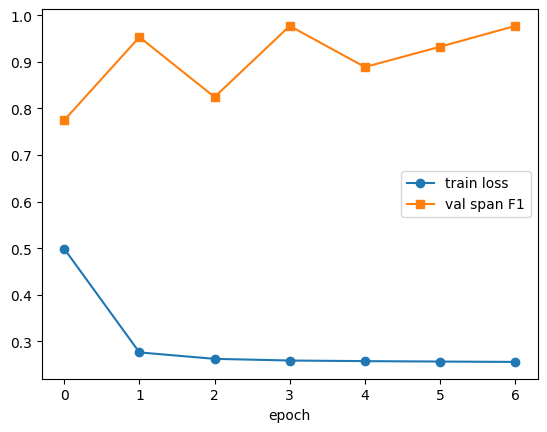

In [ ]:
hist = result["history"]
print(f"{'epoch':>5} {'loss':>8} {'val P':>7} {'val R':>7} {'val F1':>7} {'repairs':>7} {'lr':>9} {'sec':>4}")
for h in hist:
    print(f"{h['epoch']:>5} {h['train_loss']:>8.4f} {h['val_p']:>7.4f} {h['val_r']:>7.4f} "
          f"{h['val_f1']:>7.4f} {h['val_repairs']:>7} {h['lr']:>9.2e} {h['seconds']:>4.0f}")

try:
    import matplotlib.pyplot as plt
    ep = [h["epoch"] for h in hist]
    plt.plot(ep, [h["train_loss"] for h in hist], "o-", label="train loss")
    plt.plot(ep, [h["val_f1"] for h in hist], "s-", label="val span F1")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()
except ImportError:
    print("(matplotlib not installed — read the table instead: loss should fall as val F1 rises)")

Read the run: training minimizes loss, but the checkpoint *kept* is the one
with the best **validation span micro-F1** — the exact-match entity metric of
§9, computed on sentences the model never trained on. Once val F1 stops
improving for `patience` epochs, more training is just memorization, so the
loop stops. The `val_repairs` column counts invalid BIO sequences the decoder
had to repair on validation output — the rule explained next.

## 9. Decoding and scoring

Decoding reads each of the 21 columns independently as IOB2: `B-x` opens a
span, `I-x` extends it, `O` closes it. The heads label each token
independently, so output can be *invalid* — an `I-x` with no open span of
type x. The repair rule: an orphan `I-x` **starts** a new span, and every
repair is counted (on the real blind test this fired 201 times across 5,780
predicted spans, ≈3.5%).

In [ ]:
from kgeval import spans

res = spans.decode_bio_column(["O", "I-PERS", "O"], "PERS")
print("tags:  O  I-PERS  O")
print("spans:", sorted(res.spans), "| orphan-I repairs:", res.n_repairs)

tags:  O  I-PERS  O
spans: [(1, 2, 'PERS')] | orphan-I repairs: 1


Scoring is **exact span + type micro-F1**: a prediction is a true positive
only if its boundaries *and* its type match; TP/FP/FN are pooled across all
21 types, then P/R/F1 computed. That strictness is why "token accuracy" is
the wrong instinct — the all-O baseline below the real scores proves it.
(Toy numbers again: mechanics, not quality.)

In [ ]:
from kgeval import ner_scoring

test_examples = ner_data.build_examples(toy_docs["test"], tokenizer, cfg.max_len)
test_batches = ner_data.make_batches(test_examples, tokenizer, cfg.batch_size, cfg.max_len)
score, pred_docs = ner_train.evaluate(model, test_batches, toy_docs["test"], DEVICE)
print(score.pretty())

micro-P 0.9375  micro-R 0.9677  micro-F1 0.9524  (TP 60 FP 4 FN 2; IOB repairs in pred: 0)
  DATE      P 1.000 R 1.000 F1 1.000  (gold 5)
  GPE       P 0.778 R 0.875 F1 0.824  (gold 16)
  LOC       P 1.000 R 1.000 F1 1.000  (gold 4)
  OCC       P 1.000 R 1.000 F1 1.000  (gold 4)
  ORG       P 1.000 R 1.000 F1 1.000  (gold 14)
  PERS      P 1.000 R 1.000 F1 1.000  (gold 19)


In [ ]:
# Why spans and not tokens: the all-O baseline is a great "token tagger".
gold_tags = [[r[1:] for r in rows] for rows in toy_docs["test"]]
all_o = [[["O"] * 21 for _ in rows] for rows in toy_docs["test"]]
n_right = sum(g == p for gs, ps in zip(gold_tags, all_o)
              for gr, pr in zip(gs, ps) for g, p in zip(gr, pr))
n_total = sum(21 * len(rows) for rows in gold_tags)  # per-token, per-type tag slots
zero = ner_scoring.score_tag_docs(gold_tags, all_o)
print(f"all-O baseline: token accuracy {n_right / n_total:.3f}  vs  span F1 {zero.micro[2]:.3f}")
print("high 'accuracy', zero entities found — the metric must see spans, not tokens.")

all-O baseline: token accuracy 0.975  vs  span F1 0.000
high 'accuracy', zero entities found — the metric must see spans, not tokens.


## 10. Ensembling

Same data, same hyperparameters, different **seed** → a different local
optimum (init, dropout, data order). Combining seeds cancels noise when their
errors are independent. Two span-level levers: **union** (keep any span ≥1
model found — a recall lever) and **majority vote** (keep spans ≥2 models
found — a precision lever). Watch both on one fabricated 6-token sentence:

In [ ]:
# Three fabricated "models" tag the same 6-token sentence (spans = (start, end, type)).
m13 = spans.encode_spans_to_rows([(0, 2, "ORG"), (4, 5, "GPE")], 6)
m42 = spans.encode_spans_to_rows([(0, 2, "ORG"), (4, 6, "GPE")], 6)  # longer GPE — overlaps m13's
m77 = spans.encode_spans_to_rows([(0, 2, "ORG"), (5, 6, "PERS")], 6)

for mv in (1, 2):
    ens = spans.union_tag_rows([m13, m42, m77], min_votes=mv)
    print(f"min_votes={mv}: {sorted(ens.spans)}  (same-type overlaps dropped: {ens.n_dropped})")

min_votes=1: [(0, 2, 'ORG'), (4, 6, 'GPE'), (5, 6, 'PERS')]  (same-type overlaps dropped: 1)
min_votes=2: [(0, 2, 'ORG')]  (same-type overlaps dropped: 0)


Read the output: the union keeps everything — and must greedily drop the
lower-priority of two overlapping same-type spans (by votes, then length,
then position) — while the vote keeps only what most models corroborate. Now
for real: train a second quick model with seed 42 and combine both on the toy
test set. With two models, vote(2) is strict intersection; the paper used
three seeds, where vote(2) is a true majority.

In [ ]:
from dataclasses import replace

cfg42 = replace(cfg, seed=42)
model42, _, result42 = ner_train.run_training(toy_docs["train"], toy_docs["val"], cfg42, "runs/quick-s42")
print(f"seed 42 done: best val F1 {result42['best_val_f1']:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[data] 12 train / 2 val batches (size 16, tensorized in 0s)


[epoch 0] loss 0.5013 val-F1 0.8246 (P 0.9592 R 0.7231) 1s


[epoch 1] loss 0.2768 val-F1 0.9771 (P 0.9697 R 0.9846) 1s


[epoch 2] loss 0.2616 val-F1 0.9323 (P 0.9118 R 0.9538) 1s


[epoch 3] loss 0.2581 val-F1 0.9323 (P 0.9118 R 0.9538) 1s


[epoch 4] loss 0.2568 val-F1 0.9771 (P 0.9697 R 0.9846) 1s


seed 42 done: best val F1 0.9771


In [ ]:
sent_lens = [len(rows) for rows in toy_docs["test"]]
pred13 = ner_train.predict_docs(model, test_batches, sent_lens, DEVICE)
pred42 = ner_train.predict_docs(model42, test_batches, sent_lens, DEVICE)

# mean-prob: average the two models' softmax distributions, then argmax
def mean_prob_docs(m1, m2):
    m1.eval()
    m2.eval()
    mean_ids = []
    with torch.no_grad():
        for b in test_batches:
            ids = b.enc["input_ids"].to(DEVICE)
            mask = b.enc["attention_mask"].to(DEVICE)
            p = (torch.softmax(m1(ids, mask), dim=-1) + torch.softmax(m2(ids, mask), dim=-1)) / 2
            mean_ids.append(p.argmax(dim=-1).cpu())
    return ner_data.assemble_predictions(mean_ids, test_batches, sent_lens)

pred_mean = mean_prob_docs(model, model42)
union_docs = [spans.union_tag_rows([a, b], min_votes=1).rows for a, b in zip(pred13, pred42)]
vote_docs = [spans.union_tag_rows([a, b], min_votes=2).rows for a, b in zip(pred13, pred42)]

for name, pd in [("seed 13", pred13), ("seed 42", pred42), ("mean-prob", pred_mean),
                 ("union ≥1", union_docs), ("vote ≥2", vote_docs)]:
    p, r, f1 = ner_scoring.score_tag_docs(gold_tags, pd).micro
    print(f"{name:10} P {p:.4f} R {r:.4f} F1 {f1:.4f}")
print("\n(toy numbers: the combination mechanics are visible, the magnitudes are not meaningful)")

seed 13    P 0.9375 R 0.9677 F1 0.9524
seed 42    P 0.9194 R 0.9194 F1 0.9194
mean-prob  P 0.9365 R 0.9516 F1 0.9440
union ≥1   P 0.9375 R 0.9677 F1 0.9524
vote ≥2    P 0.9344 R 0.9194 F1 0.9268

(toy numbers: the combination mechanics are visible, the magnitudes are not meaningful)


What the paper found on real data: on the blind set the three seeds largely
**agree** — the union predicted only 8% more spans than the largest single
seed (6,479 vs 5,982) — so the entities being missed are missed by *every*
seed. The recall deficit is **systematic**, and a recall lever has nothing to
lever; majority vote was submitted instead, and the blind result confirmed
the reasoning: **+1.9 precision, +0.3 recall** over the single model.
In-domain (Wojood test): vote 0.9329 > mean-prob 0.9295 > single 0.9268 >
union 0.9205.

## 11. Full replication

The paper recipe, all runnable above: AraBERTv02, batch 16, max_len 512,
lr 1e-5 with γ=0.95 decay per epoch, ≤40 epochs patience 5, seed 13 — about
90 minutes on a T4. With Wojood in place (§3) and `KGEVAL_FULL=1`, the §8
config cell already selects it. That single model scored **0.9208 val /
0.9240 Wojood-test** (P 0.9169, R 0.9313).

The submitted system re-trained on train+val combined with a fixed 29-epoch
schedule (`select="last"` — folding val into training forfeits early stopping
by design), seeds 13/42/77 (~4.1 GPU-hours), and majority-vote decoding:
**0.9329 Wojood-test, 0.7483 blind Konooz** vs the single model's 0.7385
(P 0.7874→0.8060, R 0.6953→0.6982). The **18.6-point domain-shift tax falls
on recall**: in-domain recall *exceeds* precision; on Konooz it trails by 9.2
points — entities in unseen domains are missed, not mislabeled.

In [ ]:
# Full replication — runs only with real Wojood data (§3) AND KGEVAL_FULL=1.
# Everything in the else-branch is paper-exact; on the toy path this no-ops.
if real_corpus is None or not FULL_REPLICATION:
    print("no-op: needs real Wojood data (§3) and FULL_REPLICATION=1.")
    print("The §8 quick run already exercised this same code on the toy corpus.")
else:
    real_docs = {s: convert.convert_corpus(c)[0] for s, c in real_corpus.items()}

    # (a) the paper's single model — every TrainConfig default here IS the paper recipe
    paper_cfg = TrainConfig(model_name=MODEL_NAME, wall_limit_s=3.5 * 3600)
    model, tokenizer, result = ner_train.run_training(
        real_docs["train"], real_docs["val"], paper_cfg, "runs/paper-single")

    # (b) the submitted ensemble: train+val, fixed 29 epochs, no checkpoint selection
    ens_docs = real_docs["train"] + real_docs["val"]
    test_batches_full = ner_data.make_batches(
        ner_data.build_examples(real_docs["test"], tokenizer, 512), tokenizer, 16, 512)
    lens = [len(r) for r in real_docs["test"]]
    per_seed = []
    for seed in (13, 42, 77):
        m, _, _ = ner_train.run_training(
            ens_docs, ens_docs,
            replace(paper_cfg, select="last", max_epochs=29, seed=seed),
            f"runs/paper-s{seed}")
        per_seed.append(ner_train.predict_docs(m, test_batches_full, lens, DEVICE))
    vote = [spans.union_tag_rows(rs, min_votes=2).rows for rs in zip(*per_seed)]
    gold = [[r[1:] for r in rows] for rows in real_docs["test"]]
    print(ner_scoring.score_tag_docs(gold, vote).pretty())

no-op: needs real Wojood data (§3) and FULL_REPLICATION=1.
The §8 quick run already exercised this same code on the toy corpus.


## 12. Where to go next

- The paper: `paper/latex/main.tex`; the teaching companion:
  `docs/learning-corner/paper-companion.md` (loss math, decoding, protocol).
- Notebook 2 (`02-relation-extraction.ipynb`): the relation-extraction half.
- Alternatives the team rejected, with the reason each lost: **LLM in-context
  NER** (published Arabic results 0.29–0.74 F1; fine-tuned 7B models at or
  below BERT-base); **MRC-style per-type querying** (21× inference cost);
  **grid / W2NER decoders** (their distinguishing case — same-type nesting —
  is unrepresentable in the 21-column format anyway).
- Open knobs worth trying first: Tversky α<0.5 for recall, domain-adaptive
  pretraining on the unlabeled test text, a CRF decoding layer.